In [1]:

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from tqdm.auto import tqdm

torch.backends.cudnn.benchmark = True

DATASET_DIR = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/train/images"

class Config:
    dataset_dir = DATASET_DIR
    output_dir = "/kaggle/working/mae_checkpoints"

    image_size = 224
    patch_size = 16

    batch_size = 64

    epochs = 150

    learning_rate = 1.5e-4

    mask_ratio = 0.75

    embed_dim = 192
    depth = 12
    num_heads = 3

    decoder_dim = 256
    decoder_depth = 4
    decoder_heads = 8

    num_workers = 2

    seed = 42

config = Config()

os.makedirs(
    config.output_dir,
    exist_ok=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

def seed_everything(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

seed_everything(
    config.seed
)

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        config.image_size,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

In [4]:
class MAEDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform
    ):

        self.root_dir = Path(root_dir)

        self.transform = transform

        valid_extensions = {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        }

        self.image_paths = sorted([
            p
            for p in self.root_dir.rglob("*")
            if p.suffix.lower() in valid_extensions
        ])

        self.identifiers = [
            p.stem
            for p in self.image_paths
        ]

    def __len__(self):

        return len(
            self.image_paths
        )

    def __getitem__(
        self,
        idx
    ):

        path = self.image_paths[idx]

        with Image.open(path) as img:

            image = img.convert("RGB")

        image = self.transform(
            image
        )

        identifier = self.identifiers[idx]

        return image, identifier

train_dataset = MAEDataset(
    config.dataset_dir,
    train_transform
)

print(
    "Images:",
    len(train_dataset)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True,
    drop_last=True
)

Images: 19186


In [5]:
class MLP(nn.Module):

    def __init__(
        self,
        dim,
        mlp_ratio=4.0
    ):

        super().__init__()

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.net = nn.Sequential(
            nn.Linear(
                dim,
                hidden_dim
            ),
            nn.GELU(),
            nn.Linear(
                hidden_dim,
                dim
            )
        )

    def forward(
        self,
        x
    ):

        return self.net(x)


class TransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        num_heads
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(
            dim
        )

        self.attn = nn.MultiheadAttention(
            dim,
            num_heads,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(
            dim
        )

        self.mlp = MLP(dim)

    def forward(
        self,
        x
    ):

        y = self.norm1(x)

        y, _ = self.attn(
            y,
            y,
            y
        )

        x = x + y

        x = x + self.mlp(
            self.norm2(x)
        )

        return x

In [6]:
class MAE(nn.Module):

    def __init__(
        self,
        config
    ):

        super().__init__()

        self.patch_size = config.patch_size

        self.embed_dim = config.embed_dim

        self.mask_ratio = config.mask_ratio

        self.num_patches = (
            config.image_size //
            config.patch_size
        ) ** 2

        patch_dim = (
            3 *
            config.patch_size *
            config.patch_size
        )

        self.patch_embed = nn.Conv2d(
            3,
            config.embed_dim,
            kernel_size=config.patch_size,
            stride=config.patch_size
        )

        self.pos_embed = nn.Parameter(
            torch.randn(
                1,
                self.num_patches,
                config.embed_dim
            )
        )

        self.encoder = nn.ModuleList([
            TransformerBlock(
                config.embed_dim,
                config.num_heads
            )
            for _ in range(
                config.depth
            )
        ])

        self.encoder_norm = nn.LayerNorm(
            config.embed_dim
        )

        self.decoder_embed = nn.Linear(
            config.embed_dim,
            config.decoder_dim
        )

        self.mask_token = nn.Parameter(
            torch.randn(
                1,
                1,
                config.decoder_dim
            )
        )

        self.decoder_pos_embed = nn.Parameter(
            torch.randn(
                1,
                self.num_patches,
                config.decoder_dim
            )
        )

        self.decoder = nn.ModuleList([
            TransformerBlock(
                config.decoder_dim,
                config.decoder_heads
            )
            for _ in range(
                config.decoder_depth
            )
        ])

        self.decoder_norm = nn.LayerNorm(
            config.decoder_dim
        )

        self.decoder_pred = nn.Linear(
            config.decoder_dim,
            patch_dim
        )

    def patchify(
        self,
        imgs
    ):

        p = self.patch_size

        h = w = imgs.shape[2] // p

        x = imgs.reshape(
            imgs.shape[0],
            3,
            h,
            p,
            w,
            p
        )

        x = torch.einsum(
            "nchpwq->nhwpqc",
            x
        )

        x = x.reshape(
            imgs.shape[0],
            h * w,
            p * p * 3
        )

        return x

    def unpatchify(
        self,
        x
    ):

        p = self.patch_size

        h = w = int(
            x.shape[1] ** 0.5
        )

        x = x.reshape(
            x.shape[0],
            h,
            w,
            p,
            p,
            3
        )

        x = torch.einsum(
            "nhwpqc->nchpwq",
            x
        )

        imgs = x.reshape(
            x.shape[0],
            3,
            h * p,
            h * p
        )

        return imgs

    def random_masking(
        self,
        x
    ):

        N, L, D = x.shape

        len_keep = int(
            L * (1 - self.mask_ratio)
        )

        noise = torch.rand(
            N,
            L,
            device=x.device
        )

        ids_shuffle = torch.argsort(
            noise,
            dim=1
        )

        ids_restore = torch.argsort(
            ids_shuffle,
            dim=1
        )

        ids_keep = ids_shuffle[
            :,
            :len_keep
        ]

        x_masked = torch.gather(
            x,
            dim=1,
            index=ids_keep.unsqueeze(-1).repeat(
                1,
                1,
                D
            )
        )

        mask = torch.ones(
            N,
            L,
            device=x.device
        )

        mask[:, :len_keep] = 0

        mask = torch.gather(
            mask,
            dim=1,
            index=ids_restore
        )

        return (
            x_masked,
            mask,
            ids_restore
        )

    def forward_encoder(
        self,
        imgs
    ):

        x = self.patch_embed(
            imgs
        )

        x = x.flatten(2)

        x = x.transpose(1, 2)

        x = x + self.pos_embed

        x, mask, ids_restore = self.random_masking(
            x
        )

        for block in self.encoder:

            x = block(x)

        x = self.encoder_norm(
            x
        )

        return (
            x,
            mask,
            ids_restore
        )

    def forward_decoder(
        self,
        x,
        ids_restore
    ):

        x = self.decoder_embed(
            x
        )

        B, L, D = x.shape

        mask_tokens = self.mask_token.repeat(
            B,
            ids_restore.shape[1] - L,
            1
        )

        x_ = torch.cat(
            [
                x,
                mask_tokens
            ],
            dim=1
        )

        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(
                1,
                1,
                D
            )
        )

        x_ = x_ + self.decoder_pos_embed

        for block in self.decoder:

            x_ = block(x_)

        x_ = self.decoder_norm(
            x_
        )

        pred = self.decoder_pred(
            x_
        )

        return pred

    def forward(
        self,
        imgs
    ):

        latent, mask, ids_restore = self.forward_encoder(
            imgs
        )

        pred = self.forward_decoder(
            latent,
            ids_restore
        )

        return pred, mask

In [7]:
model = MAE(
    config
)

model = model.to(
    device
)

print(
    sum(
        p.numel()
        for p in model.parameters()
    ) / 1e6,
    "Million Parameters"
)

8.9808 Million Parameters


In [8]:
def mae_loss(
    imgs,
    pred,
    mask
):

    target = model.patchify(
        imgs
    )

    mean = target.mean(
        dim=-1,
        keepdim=True
    )

    var = target.var(
        dim=-1,
        keepdim=True
    )

    target = (
        target - mean
    ) / (
        var + 1e-6
    ).sqrt()

    loss = (
        pred - target
    ) ** 2

    loss = loss.mean(
        dim=-1
    )

    loss = (
        loss * mask
    ).sum() / mask.sum()

    return loss

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.epochs
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=device.type == "cuda"
)

In [10]:
tracking_ids = []

for epoch in range(
    config.epochs
):

    model.train()

    total_loss = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{config.epochs}"
    )

    epoch_ids = []

    for batch_idx, (images, identifiers) in enumerate(progress):

        images = images.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=device.type == "cuda"
        ):

            pred, mask = model(
                images
            )

            loss = mae_loss(
                images,
                pred,
                mask
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        total_loss += loss.item()

        epoch_ids.extend(
            list(
                identifiers
            )
        )

        avg_loss = total_loss / (batch_idx + 1)

        progress.set_postfix(
            avg_loss=f"{avg_loss:.4f}"
        )

    scheduler.step()

    epoch_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch+1} "
        f"Loss {epoch_loss:.4f}"
    )

    if (epoch + 1) % 30 == 0:

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "tracking_labels": epoch_ids
        }
    
        torch.save(
            checkpoint,
            os.path.join(
                config.output_dir,
                f"mae_epoch_{epoch+1}.pt"
            )
        )
    
        torch.save(
            {
                "patch_embed": model.patch_embed.state_dict(),
                "encoder": model.encoder.state_dict(),
                "encoder_norm": model.encoder_norm.state_dict(),
                "pos_embed": model.pos_embed
            },
            os.path.join(
                config.output_dir,
                f"mae_encoder_epoch_{epoch+1}.pth"
            )
        )
    
        print(
            f"Checkpoint Saved Epoch {epoch+1}"
        )

Epoch 1/150:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 1 Loss 0.8832


Epoch 2/150:   0%|          | 0/299 [00:00<?, ?it/s]

Epoch 2 Loss 0.8426


Epoch 3/150:   0%|          | 0/299 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cbcf0275c60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: if w.is_alive():
<function _MultiProcessingDataLoaderIter.__del__ at 0x7cbcf0275c60> 
Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers()  
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^
^ ^ ^ ^ ^ ^  ^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'
  ^ ^
   File "/usr/lib/py

Epoch 149 Loss 0.5250


Epoch 150/150:   0%|          | 0/299 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cbcf0275c60>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7cbcf0275c60>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    Traceback (most recent call last):
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    AssertionErrorif w.is_alive():: 
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7cbcf0275c60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/

Epoch 150 Loss 0.5244
Checkpoint Saved Epoch 150


In [11]:
torch.save(
    {
        "patch_embed": model.patch_embed.state_dict(),
        "encoder": model.encoder.state_dict(),
        "encoder_norm": model.encoder_norm.state_dict(),
        "pos_embed": model.pos_embed
    },
    os.path.join(
        config.output_dir,
        "mae_encoder_final.pth"
    )
)

In [12]:
imagenet_mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(
    1, 3, 1, 1
)

imagenet_std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(
    1, 3, 1, 1
)

def denormalize(
    x
):

    return (
        x * imagenet_std.to(x.device)
        + imagenet_mean.to(x.device)
    ).clamp(
        0,
        1
    )

In [13]:
def unnormalize_predictions(
    pred,
    target
):
    mean = target.mean(
        dim=-1,
        keepdim=True
    )

    var = target.var(
        dim=-1,
        keepdim=True
    )

    pred = pred * (
        var + 1e-6
    ).sqrt() + mean

    return pred

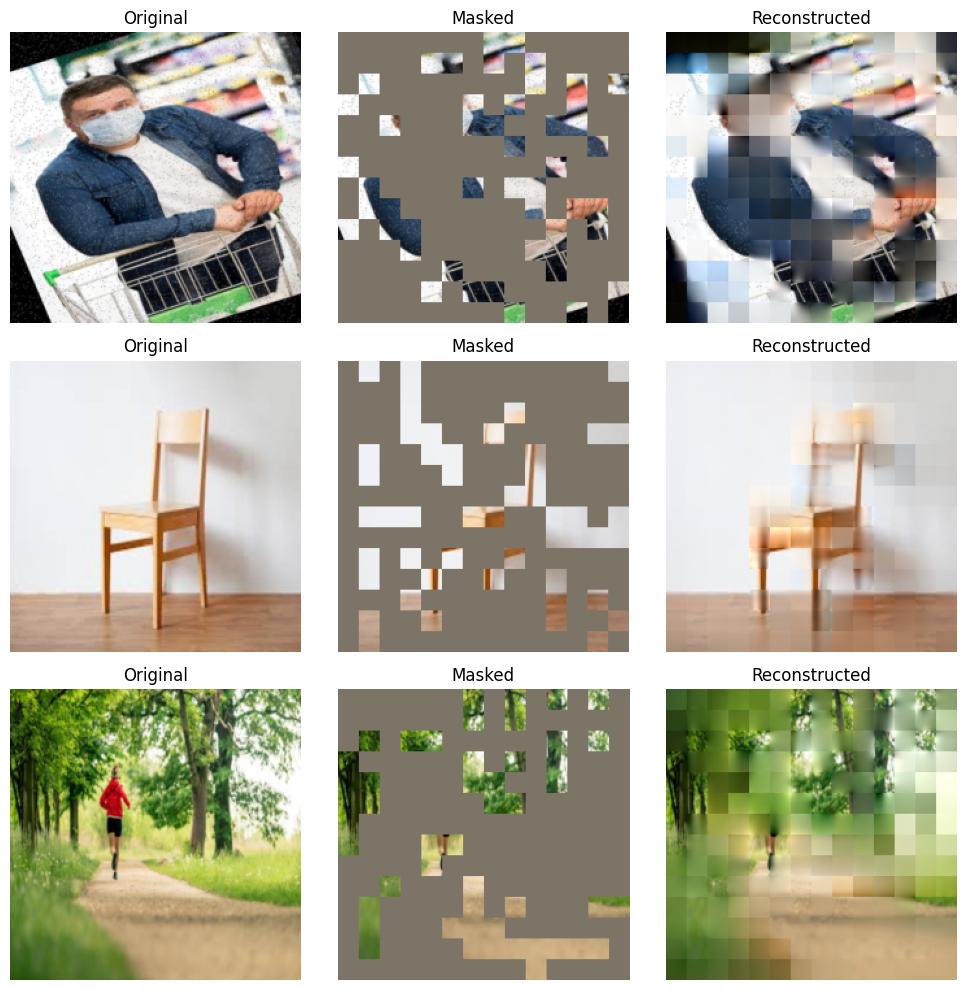

In [14]:
model.eval()



images, identifiers = next(
    iter(train_loader)
)

images = images[:3].to(
    device
)

with torch.no_grad():

    pred, mask = model(
        images
    )

target = model.patchify(
    images
)

pred = unnormalize_predictions(
    pred,
    target
)

reconstructed_patches = target.clone()

mask_expanded = mask.unsqueeze(
    -1
).repeat(
    1,
    1,
    target.shape[-1]
)

reconstructed_patches[
    mask_expanded.bool()
] = pred[
    mask_expanded.bool()
]

reconstructed = model.unpatchify(
    reconstructed_patches
)

masked_patches = target.clone()

masked_patches[
    mask_expanded.bool()
] = 0

masked_images = model.unpatchify(
    masked_patches
)

originals = denormalize(
    images
)

masked_images = denormalize(
    masked_images
)

reconstructed = denormalize(
    reconstructed
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 10)
)

for i in range(3):

    axes[i, 0].imshow(
        originals[i]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    axes[i, 1].imshow(
        masked_images[i]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    axes[i, 2].imshow(
        reconstructed[i]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    axes[i, 0].set_title(
        "Original"
    )

    axes[i, 1].set_title(
        "Masked"
    )

    axes[i, 2].set_title(
        "Reconstructed"
    )

    axes[i, 0].axis("off")
    axes[i, 1].axis("off")
    axes[i, 2].axis("off")

plt.tight_layout()

plt.show()